### 1. Import et Configuration
Avant de manipuler nos données, nous devons configurer l'environnement du Notebook :

In [1]:
import sys
import os

project_path = os.path.abspath('..')

if project_path not in sys.path:
    sys.path.append(project_path)

%load_ext autoreload
%autoreload 2
%matplotlib inline

import config
from src import data_loader, data_processing, visualization, metrics, models, storage, walk_forward_backtest

import pandas as pd
import numpy as np

print("--Modules chargés avec succès depuis le dossier parent")

--Modules chargés avec succès depuis le dossier parent


### 1. Téléchargement des données:

- Téléchargement et nettoyage : téléchargement des données historiques des actifs définis dans la configuration en s'assurant de récupérer les prix de clôtures ajustés (permet de gérer les dividendes ou split).

In [2]:
print(f"Téléchargement des données pour : {config.tickers}")
df_close = data_loader.download_portfolio_data(tickers=config.tickers,
                                                   start_date=config.start_date,
                                                   end_date=config.end_date)


Téléchargement des données pour : ['MSFT', 'NVDA', 'GOOGL', 'TSM', 'AMZN', 'V', 'BKNG', 'JNJ', 'CAT', 'WMT']
n/ Téléchargements des données


[*********************100%***********************]  10 of 10 completed


### 2. Retraitement et analyse exploratoire :
- Transformation en rendements Logarithmiques : l'utilisation des rendements logarithmiques est privilégiée car ils sont temporellement sous-additifs et leurs propriétés s'appprochent davantage de la distribtution normale, une hypothèse fondamentale de la modélisation de Markovitz.
- Test de stationnarité : la théorie de Markowitz suppose que les séries temporelles sont stationnaires (c'est-à-dire que leur moyenne et leur variance sont constantes dans le temps).
- Matrice de corrélation : Pour que la diversification fonctionne et réduise le risque global du portefeuille, nous devons observer des corrélations modérées ou faibles entre nos actif.


Aucune valeur manquante détectée

--- Test de Stationnarité (ADF) ---

AMZN: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

BKNG: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

CAT: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

GOOGL: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

JNJ: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

MSFT: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

NVDA: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

TSM: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

V: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

WMT: p-value : 0.0000
[OK] Série STATIONNAIRE (p-value < 0.05)

 Toutes les séries sont stationnnaires
Génération du graphique de corrélation des rendements journaliers


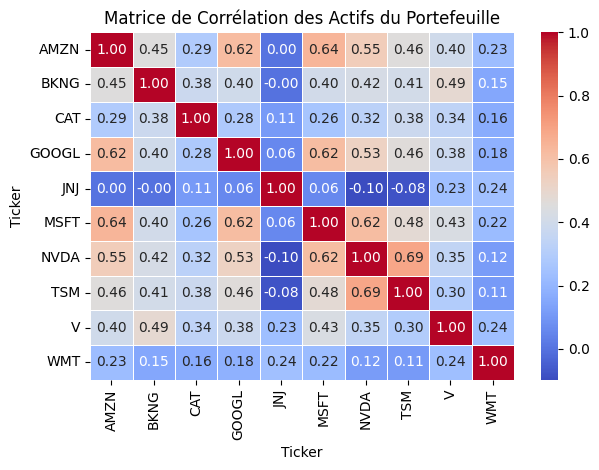

In [3]:
missing_values = data_processing.check_missing_values(df_close)

daily_log_returns, annual_log_returns = data_processing.calculate_returns(df_close)
daily_volatility = data_processing.calculate_volatility(daily_log_returns)
daily_cov_matrix, annual_cov_matrix = data_processing.calculate_cov_matrix(daily_log_returns)

# Tests de stationnarité 
data_processing.check_stationnarity(daily_log_returns)
# Matrice de corrélation des rendements
visualization.plot_correlation_matrix(daily_log_returns)

### 3. Préparation de la modélisation

In [4]:
portfolio_results = {}

# Stockage du portefeuille equal weights
ptf_ew_weights = np.array([1/len(config.tickers)] * len(config.tickers))

storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name = "Equal Weights",
    weights=ptf_ew_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate)


[OK] Modèle 'Equal Weights' stocké avec succès
1 modèle(s) au total dans le dictionnaire


### 4. Simulation de Monte Carlo : représentation de la frontière efficiente

- L'objectif de cette partie est de générer un grand nombre de portefeuilles aléatoires (15 000) pour visualiser la frontière efficiente. 
- La méthode Monte Carlo nous permet d'approximer les portefeuilles maximisant le ratio de sharpe et minimisant la volatilité.
- Portefeuille Max Sharpe Ratio = portefeuille qui offre la meilleure rentabilité par unité de risque.
- Portefeuille Min Volatility = portefeuille le plus défensif possible.
- La simulation de Monte Carlo nous sert d'outil visuel, mais elle présente une limite majeure : elle procède par tirages aléatoire. Le portefeuille affiché comme optimal n'est en réalité que la meilleure supposition parmi les 15 000 tirages effectués, et non le maximum mathématique absolu.


Lancement de la simulation Monte Carlo...(15000 itérations)
Simulation terminée : 15000 portefeuilles générés

[OK] Modèle 'Max Sharpe (Monte Carlo)' stocké avec succès
2 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Min Volatility (Monte Carlo)' stocké avec succès
3 modèle(s) au total dans le dictionnaire
Génération du graphique de la frontière efficiente


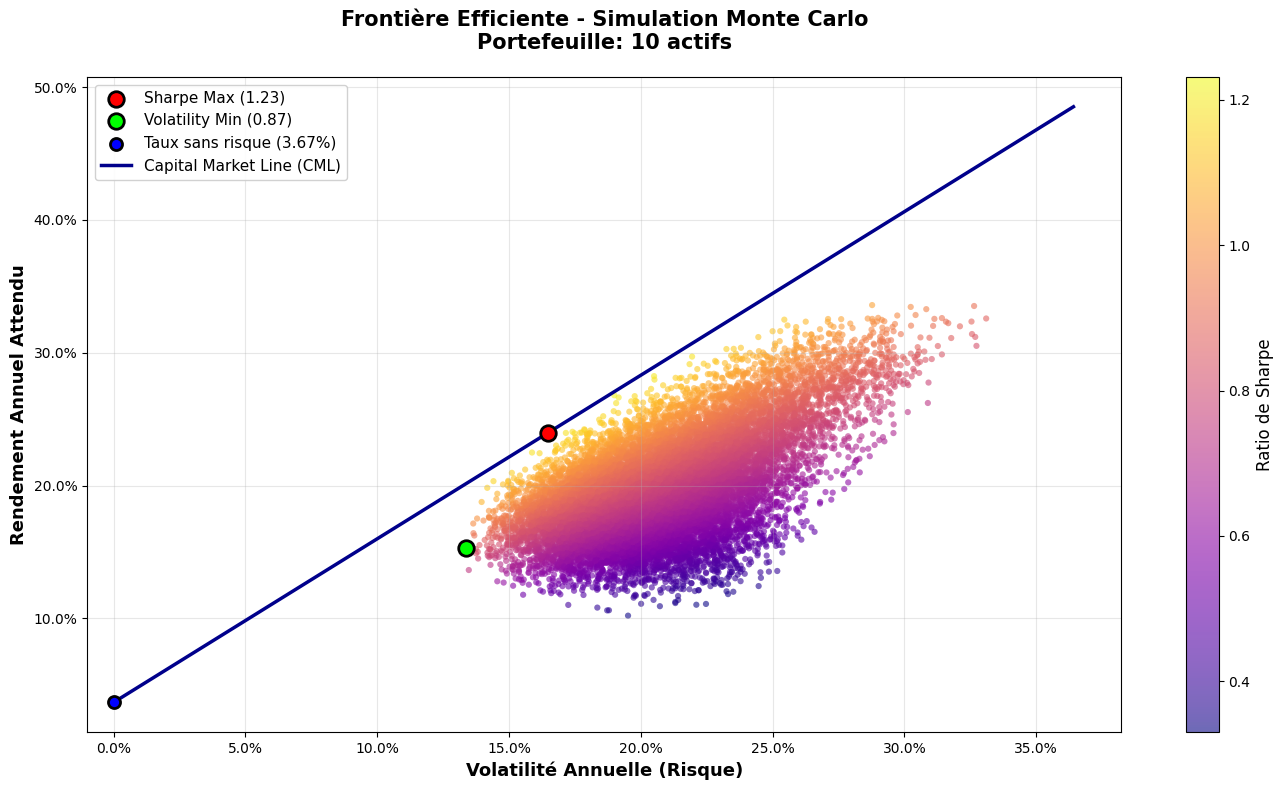

In [5]:
mc_weights, mc_returns, mc_vols, mc_sharpes = models.monte_carlo(
    nb_simulation=15000,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate,
    min_w=config.Min_weights,
    max_w=config.Max_weights)
    
# Récupération du portefeuille Max Sharpe
mc_max_sharpe_idx = mc_sharpes.argmax()
mc_max_sharpe_weights = mc_weights[mc_max_sharpe_idx]

# Récupération du portefeuille Min Volatility
mc_min_vol_idx = mc_vols.argmin()
mc_min_vol_weights = mc_weights[mc_min_vol_idx]

# Stockage dans le dictionnaire
# Max Sharpe (Monte Carlo)
storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name = "Max Sharpe (Monte Carlo)",
        weights=mc_max_sharpe_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate)
    
# Min Volatility (Monte Carlo)
storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name = "Min Volatility (Monte Carlo)",
    weights=mc_min_vol_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate)

# Visualisation de la frontière efficiente
visualization.plot_efficient_frontier(
    mc_returns=mc_returns,
    mc_vols=mc_vols,
    mc_sharpes=mc_sharpes,
    portfolio_results=portfolio_results,
    risk_free_rate=config.risk_free_rate,
    tickers=config.tickers)

### 5. Optimisation mathématique 

- L'Algorithme SLSQP nous permet de résoudre le problème sous contraintes. Il va chercher itérativement la pondération exacte qui maximise la fonction de rendement/risque, tout en s'assurant que la somme des poids reste égale à 100% et que les poids des actifs respectent nos contraintes.
- Nous générons ensuite un tableau de comparaison entre les différents modèles ainsi qu'un graphique de visualisation des poids optimaux.


Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Min Volatility

[OK] Modèle 'Max Sharpe (Optimisation | Covariance Standard)' stocké avec succès
4 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Min Volatility  (Optimisation | Covariance Standard)' stocké avec succès
5 modèle(s) au total dans le dictionnaire

TABLEAU COMPARATIF DES MODÈLES
+------------------------------------------------------+-------------+--------------+----------+
|                                                      |  Rendement  |  Volatilité  |   Sharpe |
|------------------------------------------------------+-------------+--------------+----------|
|                    Equal Weights                     |   19.88%    |    19.97%    |     0.81 |
|               Max Sharpe (Monte Carlo)               |   23.97%    |    16.49%    |     1.23 |
|   Max Sharpe (Optimisation | Covariance Standard)    |   26.67%    |    17.05%    |     1.35 |
| Min Volatility  (Optimisation | Covariance Stan

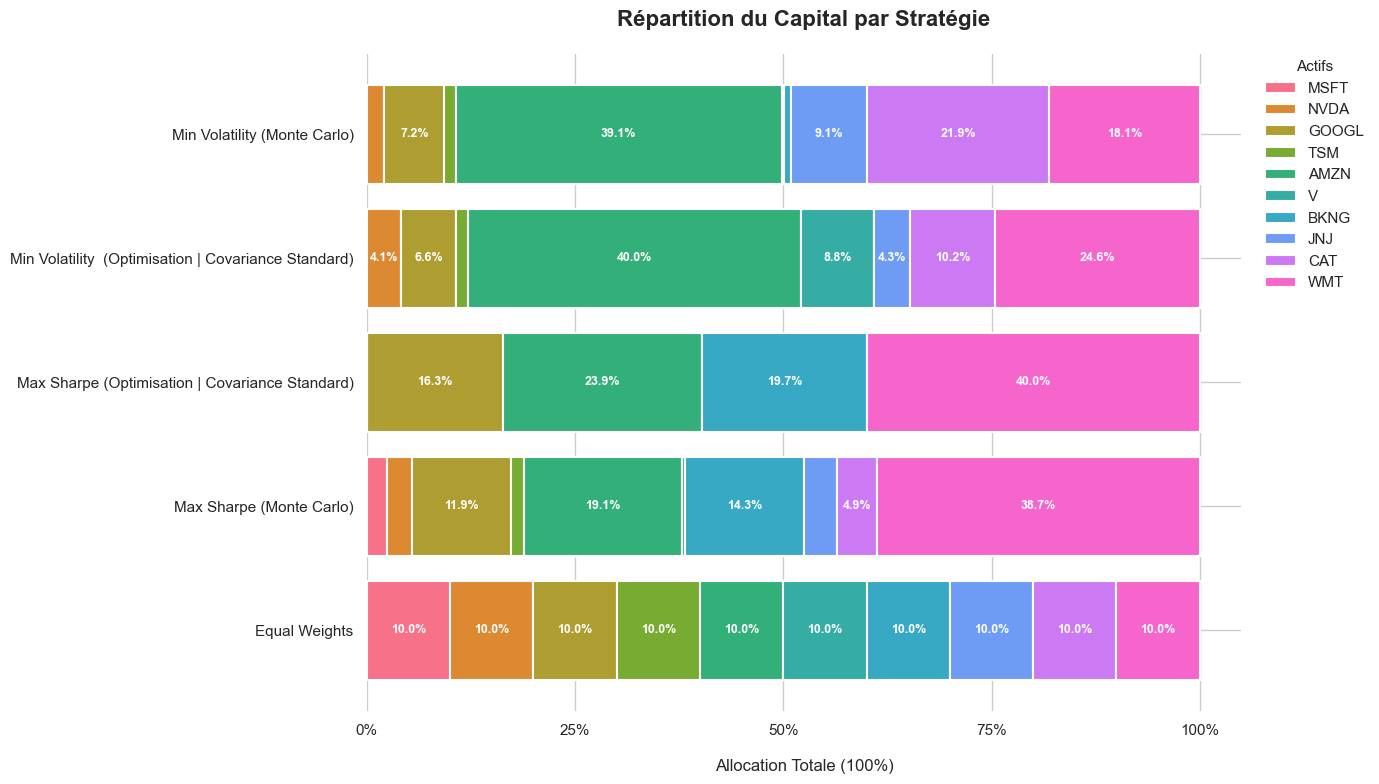

In [6]:
# Optimisation Max Sharpe
opti_max_sharpe_weights = models.optimize_max_sharpe(
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate,
    min_w=config.Min_weights,
    max_w=config.Max_weights
)
    

# Optimisation Min Vol
opti_min_vol_weights = models.optimize_min_vol(
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    min_w=config.Min_weights,
    max_w=config.Max_weights
)

# Stockage
# Max Sharpe (Covariance Standard)
storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name= "Max Sharpe (Optimisation | Covariance Standard)",
    weights=opti_max_sharpe_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)

# Min Vol (Covariance Standard)
storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name= "Min Volatility  (Optimisation | Covariance Standard)",
    weights=opti_min_vol_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)


# Tableau comparatif des modèles
visualization.display_model_comparison(portfolio_results)

visualization.plot_model_allocations(portfolio_results, config.tickers)

#### Interprétation : 

- L'algorithme SLSQP parvient systématiquement à trouver un Ratio de Sharpe légèrement supérieur et une volatilité minimale plus faible que la simulation de Monte Carlo. 
- Cependant l'optimiseur de Markowitz est sensible aux paramètres d'entrée (les rendements moyens historiques et la matrice de covariance).
- Bien que mathématiquement parfaits sur les données historiques, les portefeuilles optimisés (notamment le Max Sharpe) sont très concentrés sur un petit nombre d'actifs, poussant leurs poids jusqu'à notre limite maximale autorisée (40%).
- Si une action a affiché un rendement historique légèrement supérieur aux autres, l'algorithme va exploiter aveuglément cette différence en y allouant le maximum de capital permis, au détriment d'une véritable diversification.
- Pour pallier cette hyper-sensibilité au bruit du marché, nous allons introduire dans l'étape suivante la matrice de covariance de Ledoit-Wolf.

### 6. Optimisation : La Matrice de Covariance de Ledoit-Wolf (Shrinkage)

- Comme nous l'avons vu, l'optimisation classique de Markowitz a un défaut majeur : elle considère la matrice de covariance historique comme une vérité absolue. Or, sur les marchés financiers, les corrélations passées contiennent beaucoup de "bruit" aléatoire (des variations aberrantes qui ne se reproduiront pas).
- Pour obtenir des allocations plus équilibrées et robustes, nous utilisons la technique de Shrinkage de Ledoit-Wolf:
- Cette méthode mathématique fait un compromis entre la matrice de covariance historique (très précise sur le passé mais bruyante) et une matrice structurée théorique (très stable mais biaisée).
- Nous relançons nos deux optimisations (Max Sharpe et Min Volatility) en utilisant cette nouvelle matrice de risque.
- Pour l'évaluation finale dans notre tableau, nous re-calculons les métriques de performance sur la base de la matrice standard (afin de conserver une  équité de comparaison entre toutes nos méthodes d'optimisation).

L'intensité de shrinkage est de : 0.01053556723568006

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Min Volatility

[OK] Modèle 'Max Sharpe (Optimisation | Covariance Ledoit Wolf)' stocké avec succès
6 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Min Volatility  (Optimisation | Covariance Ledoit Wolf)' stocké avec succès
7 modèle(s) au total dans le dictionnaire

TABLEAU COMPARATIF DES MODÈLES
+---------------------------------------------------------+-------------+--------------+----------+
|                                                         |  Rendement  |  Volatilité  |   Sharpe |
|---------------------------------------------------------+-------------+--------------+----------|
|                      Equal Weights                      |   19.88%    |    19.97%    |     0.81 |
|                Max Sharpe (Monte Carlo)                 |   23.97%    |    16.49%    |     1.23 |
|   Max Sharpe (Optimisation | Covariance Ledoit Wolf)    |   26.80%   

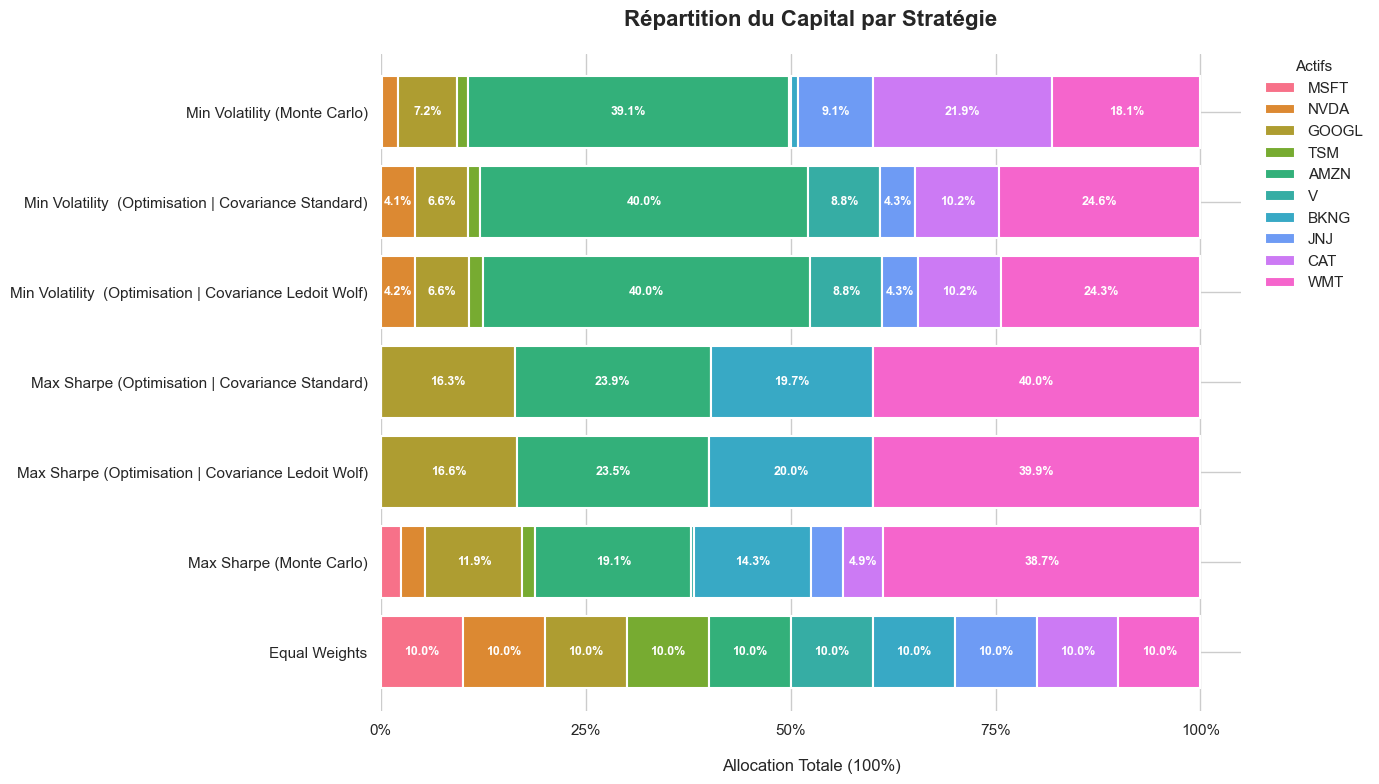

In [7]:
# Calcul de la covariance Ledoit Wolf
lw_annual_cov_matrix = data_processing.calculate_ledoitwolf_cov(daily_log_returns)

# Optimisation Max Sharpe | Covariance Ledoit Wolf
lw_opti_max_sharpe_weights = models.optimize_max_sharpe(
    annual_returns=annual_log_returns,
    cov_matrix=lw_annual_cov_matrix,
    risk_free_rate=config.risk_free_rate,
    min_w=config.Min_weights,
    max_w=config.Max_weights
)

# Optimisation Min Vol | Covariance Ledoit Wolf
lw_opti_min_vol_weights = models.optimize_min_vol(
    annual_returns=annual_log_returns,
    cov_matrix=lw_annual_cov_matrix,
    min_w=config.Min_weights,
    max_w=config.Max_weights
)


# Stockage
# Max Sharpe (Covariance Ledoit Wolf)
storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name= "Max Sharpe (Optimisation | Covariance Ledoit Wolf)",
    weights=lw_opti_max_sharpe_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix, # On utilise ici la covariance standard pour avoir une même base de comparaison entre les modèles
    risk_free_rate=config.risk_free_rate
)

# Min Vol (Covariance Ledoit Wolf)
storage.store_portfolio_model(
    storage_dict=portfolio_results,
    name= "Min Volatility  (Optimisation | Covariance Ledoit Wolf)",
    weights=lw_opti_min_vol_weights,
    annual_returns=annual_log_returns,
    cov_matrix=annual_cov_matrix, # On utilise ici la covariance standard pour avoir une même base de comparaison entre les modèles
    risk_free_rate=config.risk_free_rate
)


# Tableau comparatif des modèles
visualization.display_model_comparison(portfolio_results)

visualization.plot_model_allocations(portfolio_results, config.tickers)

#### Interprétation : 
- Comme affiché par notre algorithme ci-dessus, l'intensité de shrinkage (le coefficient de rétrécissement) calculée par la méthode de Ledoit-Wolf est d'environ 0,1. Une valeur de 0,1 est plutôt faible. Cela indique que notre matrice de covariance historique originale est déjà de très bonne qualité statistique.
- La correction apportée par Ledoit-Wolf vient légèrement "nettoyer" le bruit statistique pour rendre le modèle mathématiquement plus robuste mais sans bouleverser radicalement l'allocation par rapport à l'optimisation standard.

### 7. Métrique de performance des modèles : 

Nous avons évalué nos portefeuilles principalement avec le Ratio de Sharpe, qui utilise la volatilité totale comme mesure de risque. Le problème de la volatilité totale est qu'elle pénalise autant les fortes hausses que les fortes baisses.

Pour une analyse pplus appronfondie, nous allons nous concentrer avant tout sur le risque de perte en capital. 
Dans ce bloc, nous allons recalculer et rassembler nos modèles statiques générés jusqu'ici dans un tableau comparatif, en y intégrant des métriques avancées de gestion des risques :

- Max Drawdown & Recovery Time : la chute maximale historique depuis un sommet et le nombre de jours nécessaires pour remonter.  
- VaR 95% (Value at Risk) : la perte journalière maximale à laquelle on peut s'attendre dans 95% des cas.
- CVaR 95% (Expected Shortfall) : si les 5% des pires scénarios se réalisent (krach boursier, "cygne noir"), quelle sera notre perte moyenne ? C'est la mesure ultime du *Tail Risk* (risque de queue). 
- Ratio de Sortino : une amélioration du ratio de Sharpe qui ne pénalise que la volatilité négative.
- Ratio de Calmar : le ratio entre le rendement annuel et le Max Drawdown (plus il est élevé, plus le rendement justifie le stress subi lors des baisses).

In [8]:

# Nouveau dictionnaire de stockage des modèles avec calcul des métriques
portfolio_results_metrics = {}

# Equal Weights
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Equal Weights",
    weights=ptf_ew_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)

# Max Sharpe (Monte Carlo)
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Max Sharpe (Monte Carlo)",
    weights=mc_max_sharpe_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)

# Min Volatility (Monte Carlo)
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Min Volatility (Monte Carlo)",
    weights=mc_min_vol_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)

# Max Sharpe (Covariance Standard)
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Max Sharpe (Optimisation | Covariance Standard)",
    weights=opti_max_sharpe_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)

# Min Vol (Covariance Standard)
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Min Volatility  (Optimisation | Covariance Standard)",
    weights=opti_min_vol_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=config.risk_free_rate
)

# Max Sharpe (Covariance Ledoit Wolf)
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Max Sharpe (Optimisation | Covariance Ledoit Wolf)",
    weights=lw_opti_max_sharpe_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix, # On utilise ici la covariance standard pour avoir une même base de comparaison entre les modèles
    risk_free_rate=config.risk_free_rate
)

# Min Vol (Covariance Ledoit Wolf)
storage.store_portfolio_model_metrics(
    storage_dict=portfolio_results_metrics,
    name="Min Volatility  (Optimisation | Covariance Ledoit Wolf)",
    weights=lw_opti_min_vol_weights,
    annual_returns=annual_log_returns,
    daily_returns=daily_log_returns,
    cov_matrix=annual_cov_matrix, # On utilise ici la covariance standard pour avoir une même base de comparaison entre les modèles
    risk_free_rate=config.risk_free_rate
    )


# Tableau comparatif des modèles
visualization.display_model_comparison_metrics(portfolio_results_metrics)


[OK] Modèle 'Equal Weights' stocké avec calcul des métriques
1 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Max Sharpe (Monte Carlo)' stocké avec calcul des métriques
2 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Min Volatility (Monte Carlo)' stocké avec calcul des métriques
3 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Max Sharpe (Optimisation | Covariance Standard)' stocké avec calcul des métriques
4 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Min Volatility  (Optimisation | Covariance Standard)' stocké avec calcul des métriques
5 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Max Sharpe (Optimisation | Covariance Ledoit Wolf)' stocké avec calcul des métriques
6 modèle(s) au total dans le dictionnaire

[OK] Modèle 'Min Volatility  (Optimisation | Covariance Ledoit Wolf)' stocké avec calcul des métriques
7 modèle(s) au total dans le dictionnaire

TABLEAU COMPARATIF AVANCÉ DES MODÈLES
+------------------------------------------------------

#### Interprétation : 
 
- Le portefeuille équipondéré (Equal Weights) est notre référence "naïve". C'est de loin le moins performant : il offre le ratio de Sharpe le plus bas (0.76) et  le Max Drawdown le plus violent (-31.75%). Il lui a fallu plus d'un an (400 jours) pour récupérer sa mise initiale après son pire krach. L'optimisation mathématique prouve ici toute son utilité pour protéger le capital.
- L'optimisation "Max Sharpe" maximise agressivement la croissance (jusqu'à 26% de rendement annuel) et dégage les meilleurs ratios de rentabilité (Calmar > 1), assumant logiquement une volatilité plus élevée.
- Les modèles "Min Vol" remplissent parfaitement leur mandat de protection en limitant la volatilité sous les 13% et en divisant presque par deux les pertes extrêmes (Max Drawdown réduit à -16.9%) par rapport à l'approche équipondérée.

### 8. Analyse Walk-Forward 

Jusqu'à présent, nos optimisations étaient "statiques" (In-Sample) : elles prenaient toute la période historique d'un bloc pour calculer une seule pondération. Le danger majeur de cette méthode est l'Overfitting : l'algorithme "connaît" déjà le futur et triche en créant un portefeuille parfait pour le passé.

Pour tester la viabilité réelle de notre stratégie, nous utilisons la méthode Walk-Forward (Fenêtre Glissante) : 
1. Entraînement (Train) : L'algorithme observe le marché sur une fenêtre passée (les 2 dernières années). Il calcule les matrices de covariance et optimise les poids.
2. Test (Out-of-Sample) : Nous "gelons" ces poids et investissons sur la période suivante (les 3 mois suivants). C'est la performance réelle et aveugle de notre modèle.
3. Glissement (Rolling) : La fenêtre avance de 3 mois, et on recommence (nouvel entraînement, nouveau test) jusqu'à aujourd'hui.

Changer la composition d'un portefeuille a un coût. Notre fonction calcule le Turnover (le taux de rotation des actifs) à chaque rééquilibrage trimestriel et déduit automatiquement les coûts de transaction.

Dans ce bloc :
- Nous exécutons ce backtest glissant pour nos deux stratégies (Max Sharpe et Min Volatility).
- Nous générons un graphique d'évolution des pondérations.
- Nous traçons la courbe de performance cumulée de ces stratégies dynamiques.


Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Max Sharpe

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

Lancement de l'optimisation Min Volatility

[OK] Stratégie Out Of Sample '[WF] Max Sharpe' stockée avec succès
1 modèle

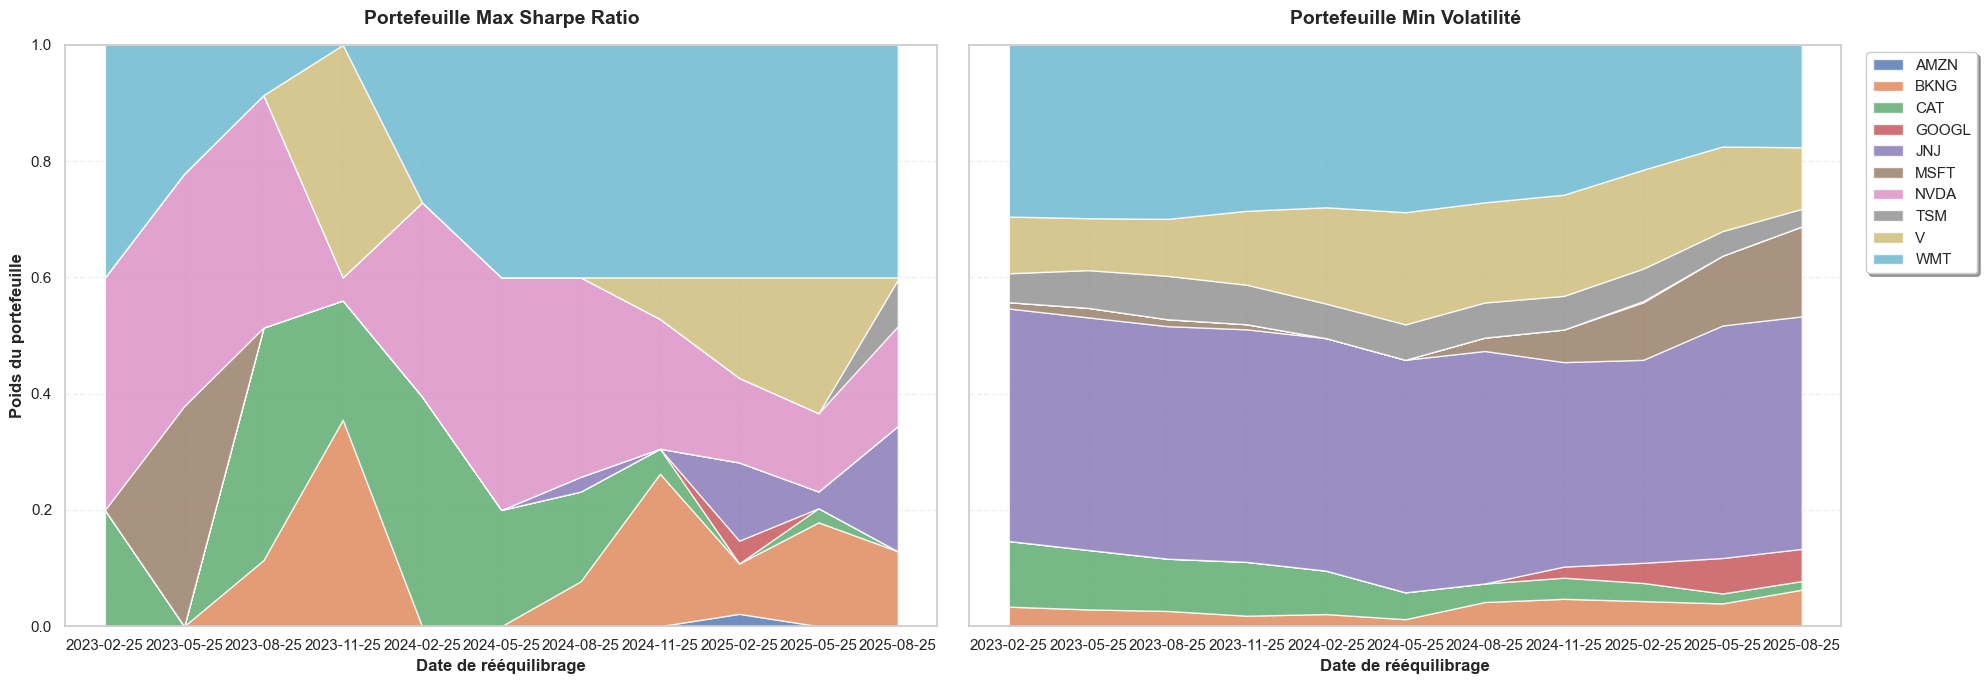

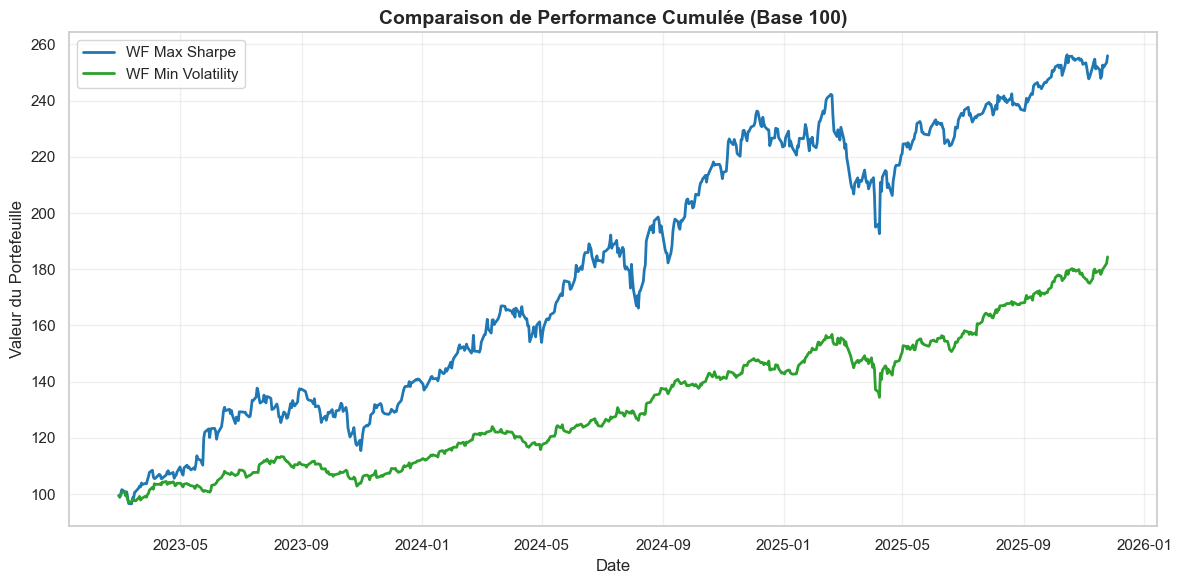

In [9]:
# Dictionnaire de stockage des résultats de l'analyse walk forward
walk_forward_result = {}

# WF Max Sharpe (Covariance Ledoit Wolf)
wf_max_sharpe_returns, wf_max_sharpe_weights = walk_forward_backtest.walk_forward_analysis(
    df_close = df_close,
    model_function=models.optimize_max_sharpe,
    train_years=config.train_years,
    test_months=config.test_months,
    risk_free_rate=config.risk_free_rate,
    max_w=config.Max_weights,
    min_w=config.Min_weights,
    transaction_cost=config.transaction_cost
)

# WF Min Volatility (Covariance Ledoit Wolf)
wf_min_vol_returns, wf_min_vol_weights = walk_forward_backtest.walk_forward_analysis(
    df_close = df_close,
    model_function=models.optimize_min_vol,
    train_years=config.train_years,
    test_months=config.test_months,
    risk_free_rate=config.risk_free_rate,
    max_w=config.Max_weights,
    min_w=config.Min_weights,
    transaction_cost=config.transaction_cost
)

# Stockage des résultats
# WF Max Sharpe (Covariance Ledoit Wolf)
storage.store_portfolio_model_walkforward(
    storage_dict=walk_forward_result,
    name="[WF] Max Sharpe",
    wf_returns=wf_max_sharpe_returns,
    risk_free_rate=config.risk_free_rate
)


# WF Min Volatility (Covariance Ledoit Wolf)
storage.store_portfolio_model_walkforward(
    storage_dict=walk_forward_result,
    name="[WF] Min Volatility",
    wf_returns=wf_min_vol_returns,
    risk_free_rate=config.risk_free_rate
)


# Visualisation graphique 
print("Génération des graphiques de backtest walk forward")

visualization.plot_walk_foward_weights(
    wf_weights_max_sharpe=wf_max_sharpe_weights,
    wf_weights_min_vol=wf_min_vol_weights)
    

visualization.plot_wf_performance(
    wf_returns_max_sharpe=wf_max_sharpe_returns,
    wf_returns_min_vol=wf_min_vol_returns)

#### Interprétation :

L'analyse visuelle de notre backtest Walk-Forward révèle deux comportements différents entre nos stratégies :
- La forte rotation (Turnover) du Max Sharpe vs la stabilité du Min Volatility : en observant l'évolution des pondérations dans le temps, on constate que le modèle Max Sharpe modifie très fréquemment son allocation. À l'inverse, le Min Volatility est beaucoup plus stable et conserve ses positions défensives (comme Walmart ou P&G) sur de longues périodes.
- La surperformance du Max Sharpe = la prime de risque: sur le graphique de performance cumulée, le Max Sharpe surperforme nettement le Min Volatility. C'est le résultat logique de sa conception : en acceptant une volatilité plus élevée et en chassant activement la dynamique haussière des valeurs de croissance (Tech), le Max Sharpe capte pleinement la prime de risque offerte par les marchés haussiers. Le Min Volatility, par nature, sacrifie cette performance pour s'assurer que sa courbe reste la plus lisse possible lors des tempêtes boursières.

### 9 . Comparaison benchmark

La question fondamentale à laquelle nous devons répondre maintenant est : Notre gestion active et nos algorithmes ont-ils créé de la valeur par rapport à un simple investissement dans un ETF ?

Pour cela, nous introduisons nos indices de référence : le S&P 500 (SPY) pour le marché global américain, et le Nasdaq-100 (QQQ) pour représenter la forte composante technologique de notre portefeuille.

Dans cette dernière étape, nous procédons à une analyse complète :
1. Évaluation absolue globale : nous alignons temporellement les données et nous calculons les métriques de risque de nos stratégies Walk-Forward face aux indices.
2. Métriques relatives : 
    - Alpha de Jensen : la surperformance "pure" de notre algorithme décorrélée du marché. Un Alpha positif prouve que notre optimisation a réellement créé de la valeur.
    - Beta : la sensibilité de nos modèles aux mouvements du marché. (Un Beta < 1 sur notre Min Volatility prouvera son caractère défensif).
    - Tracking Error & Information Ratio : mesurent la régularité avec laquelle nous battons l'indice de référence.
3. Visualisation :
    - Performance Cumulée
    - Analyse des Drawdowns : la capacité de l'algorithme à amortir les krachs par rapport au S&P 500.
    - Distribution des Rendements : analyse du Skewness (asymétrie) et du Kurtosis (queues épaisses ou "Fat Tails") pour vérifier l'exposition de nos portefeuilles aux événements extrêmes (cygnes noirs) par rapport à une loi normale.

n/ Téléchargements des données


[*********************100%***********************]  2 of 2 completed



Aucune valeur manquante détectée
None

[OK] Stratégie Out Of Sample '[Benchmark] S&P 500' stockée avec succès
3 modèle(s) au total dans le dictionnaire

[OK] Stratégie Out Of Sample '[Benchmark] NASDAQ 100' stockée avec succès
4 modèle(s) au total dans le dictionnaire

[OK] Stratégie Out Of Sample '[Benchmark] Equal Weights' stockée avec succès
5 modèle(s) au total dans le dictionnaire

TABLEAU COMPARATIF AVANCÉ DES MODÈLES
+---------------------------+-------------+--------------+----------+-----------+----------+----------------+--------------------+-------------+--------------+
|                           |  Rendement  |  Volatilité  |   Sharpe |   Sortino |   Calmar |  Max Drawdown  |   Recovery (Jours) |  VaR (95%)  |  CVaR (95%)  |
|---------------------------+-------------+--------------+----------+-----------+----------+----------------+--------------------+-------------+--------------|
| [Benchmark] Equal Weights |   33.64%    |    17.64%    |     1.7  |      2.33 |     1.55 

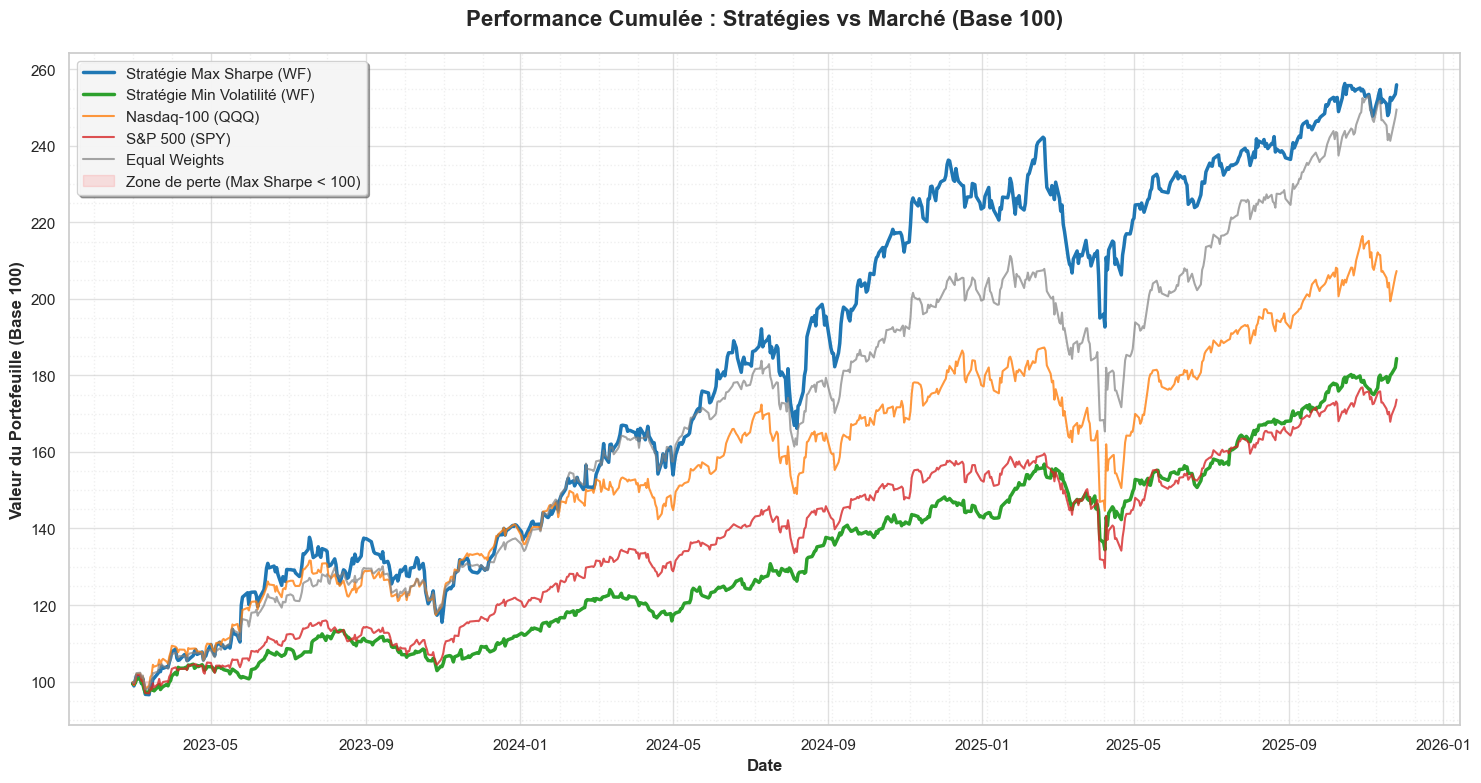


Génération du graphique comparatif des Drawdowns...


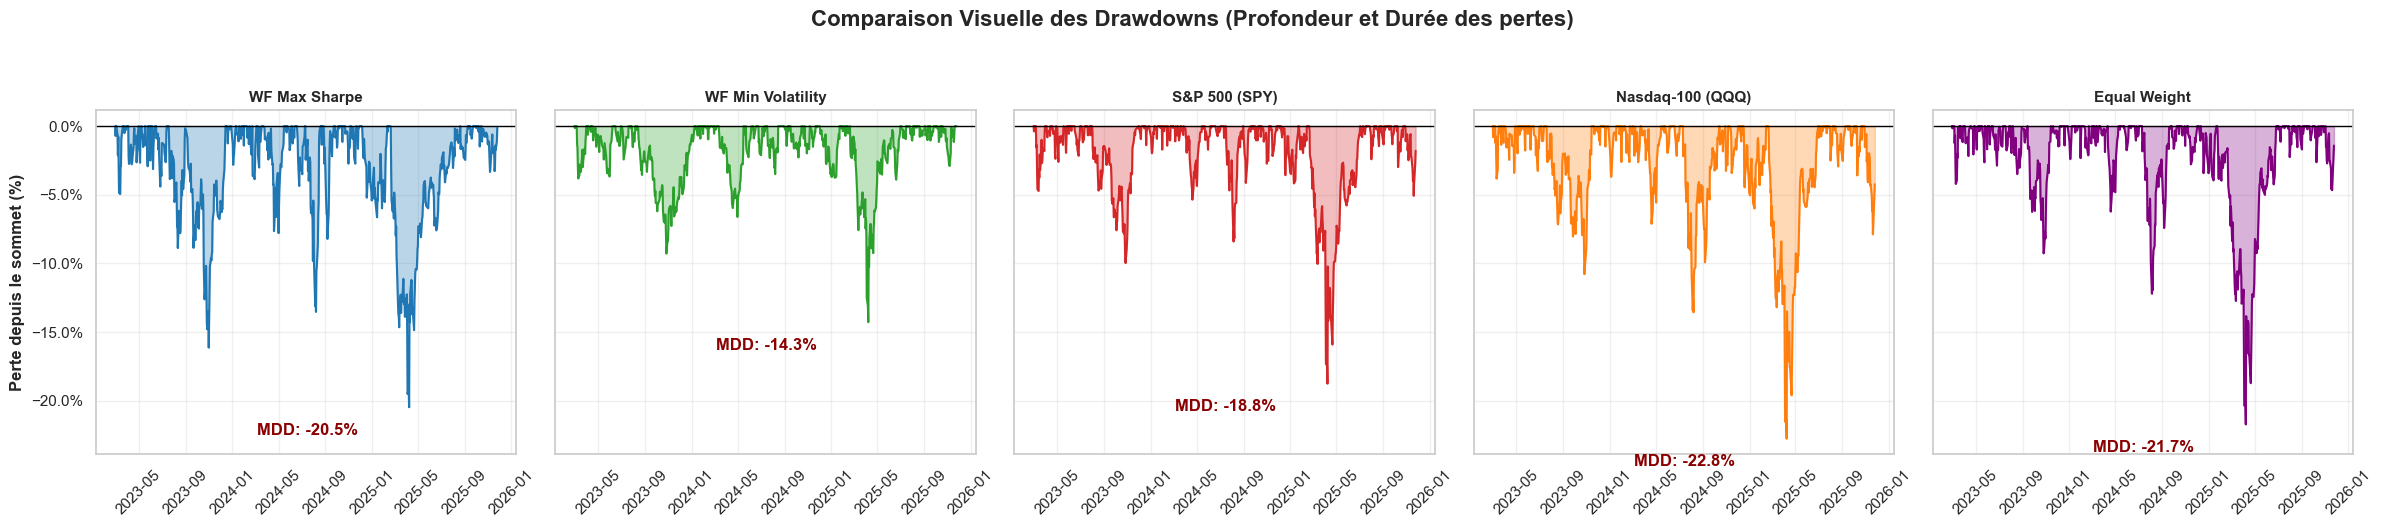


Génération du graphique de distribution des rendements...


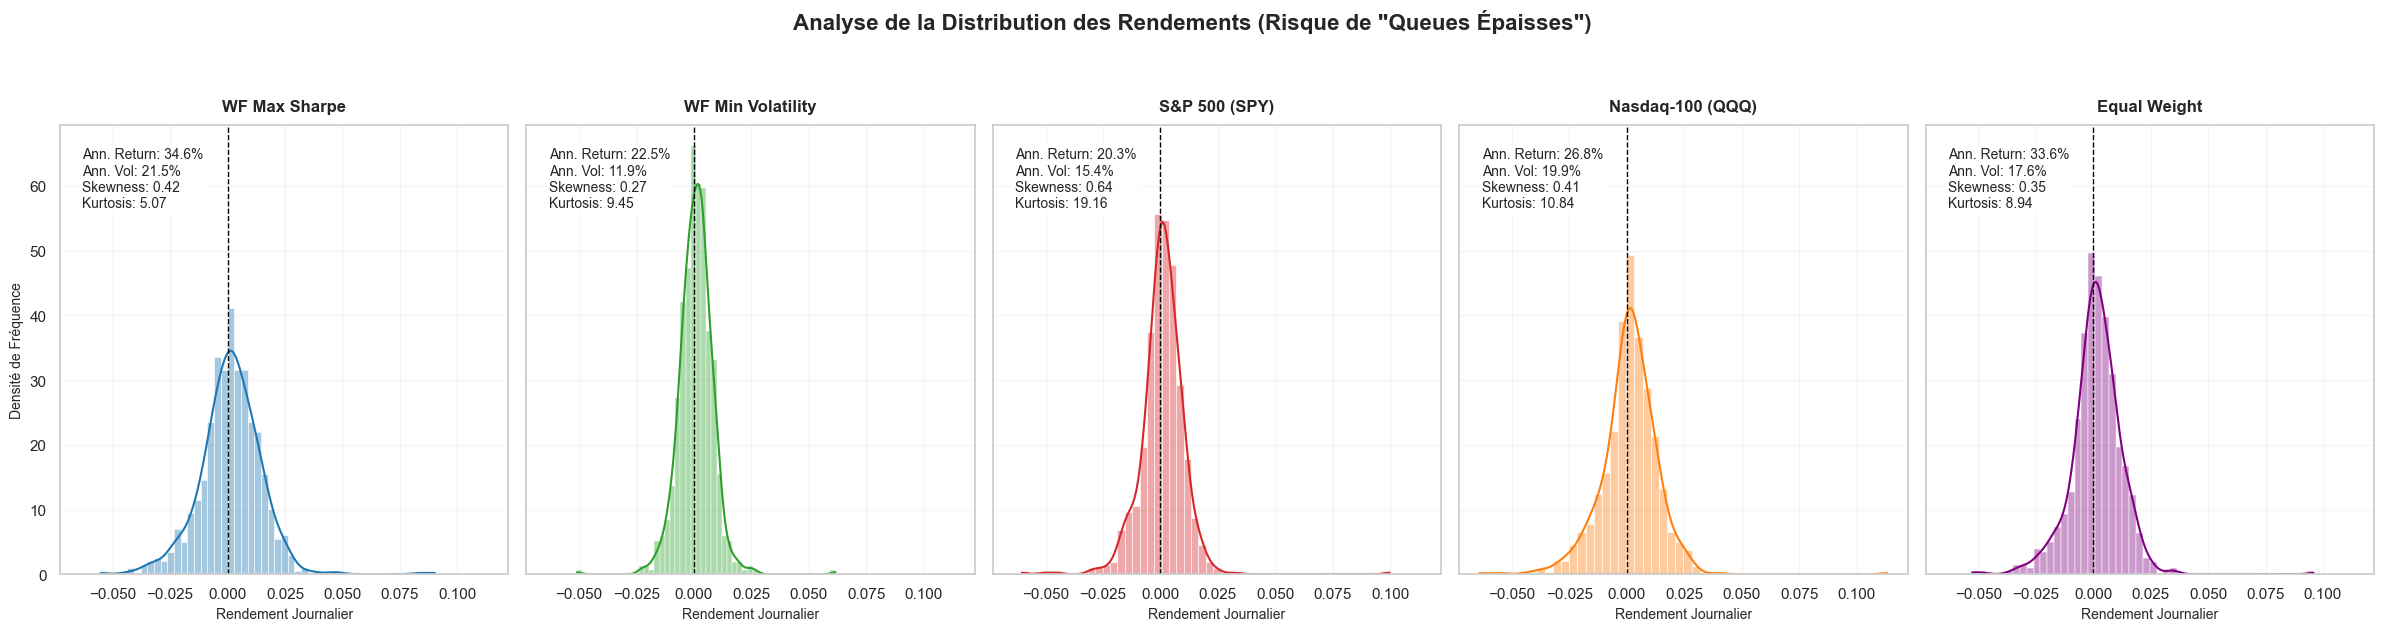

In [10]:
# Téléchargement des données
df_benchmark = data_loader.download_portfolio_data(tickers=config.benchmark_tickers,
                                                   start_date=config.start_date,
                                                   end_date=config.end_date)


# Valeurs manquantes
benchmark_missing_values = data_processing.check_missing_values(df_benchmark)
print(benchmark_missing_values)


# Calcul des rendements
benchmark_daily_log_returns, _ = data_processing.calculate_returns(df_benchmark)


# On récupère le portefeuille Equal weights
ew_daily_returns_series = daily_log_returns.dot(ptf_ew_weights)

# Alignement des dates avec celles de l'analyse walf forward
aligned_benchmark_log_returns = benchmark_daily_log_returns.reindex(wf_max_sharpe_returns.index).fillna(0)
aligned_ew_returns = ew_daily_returns_series.reindex(wf_max_sharpe_returns.index).fillna(0)

# Calcul des métriques de performance
# S&P500
storage.store_portfolio_model_walkforward(
    storage_dict=walk_forward_result,
    name="[Benchmark] S&P 500",
    wf_returns=aligned_benchmark_log_returns['SPY'],
    risk_free_rate=config.risk_free_rate
)

# NASDAQ 100
storage.store_portfolio_model_walkforward(
    storage_dict=walk_forward_result,
    name="[Benchmark] NASDAQ 100",
    wf_returns=aligned_benchmark_log_returns['QQQ'],
    risk_free_rate=config.risk_free_rate
)

# Equal Weights
storage.store_portfolio_model_walkforward(
    storage_dict=walk_forward_result,
    name="[Benchmark] Equal Weights",
    wf_returns=aligned_ew_returns,
    risk_free_rate=config.risk_free_rate
)

# Comparaison des métriques de performances
visualization.display_model_comparison_metrics(walk_forward_result)


#Initialisation du dictionnaire pour calcul des métriques relatives
wf_relative_metrics = {}


# Calcul des métriques relatives

# Max Sharpe vs S&P500
storage.store_relative_metrics(
    storage_dict=wf_relative_metrics,
    name='[WF] Max Sharpe vs S&P500',
    ptf_daily_returns=wf_max_sharpe_returns,
    benchmark_returns=aligned_benchmark_log_returns['SPY'],
    risk_free_rate=config.risk_free_rate
)

# Max Sharpe vs NASDAQ
storage.store_relative_metrics(
    storage_dict=wf_relative_metrics,
    name='[WF] Max Sharpe vs NASDAQ 100',
    ptf_daily_returns=wf_max_sharpe_returns,
    benchmark_returns=aligned_benchmark_log_returns['QQQ'],
    risk_free_rate=config.risk_free_rate
)


# Min Volatility vs S&P500
storage.store_relative_metrics(
    storage_dict=wf_relative_metrics,
    name='[WF] Min Volatility vs S&P500',
    ptf_daily_returns=wf_min_vol_returns,
    benchmark_returns=aligned_benchmark_log_returns['SPY'],
    risk_free_rate=config.risk_free_rate
)

# Min Volatility vs NASDAQ 100
storage.store_relative_metrics(
    storage_dict=wf_relative_metrics,
    name='[WF] Min Volatility vs NASDAQ 100',
    ptf_daily_returns=wf_min_vol_returns,
    benchmark_returns=aligned_benchmark_log_returns['QQQ'],
    risk_free_rate=config.risk_free_rate
)

# Comparaison des métriques de performances
visualization.display_relative_metrics(wf_relative_metrics)


# Représentation graphique des performances cumulées
visualization.plot_comparative_performance(
    wf_max_sharpe_returns=wf_max_sharpe_returns,
    wf_min_vol_returns=wf_min_vol_returns,
    sp500_returns=aligned_benchmark_log_returns['SPY'],
    nasdaq_returns=aligned_benchmark_log_returns['QQQ'],
    ew_returns=aligned_ew_returns
)


# Représentation graphique des drawdown
visualization.plot_comparative_drawdowns(
    wf_max_sharpe_returns=wf_max_sharpe_returns,
    wf_min_vol_returns=wf_min_vol_returns,
    sp500_returns=aligned_benchmark_log_returns['SPY'],
    nasdaq_returns=aligned_benchmark_log_returns['QQQ'],
    ew_returns=aligned_ew_returns
)

# Représentation graphique de la distribution des rendements
visualization.plot_return_distributions(
    wf_max_sharpe_returns=wf_max_sharpe_returns,
    wf_min_vol_returns=wf_min_vol_returns,
    sp500_returns=aligned_benchmark_log_returns['SPY'],
    nasdaq_returns=aligned_benchmark_log_returns['QQQ'],
    ew_returns=aligned_ew_returns
)

#### Interprétation : 

Le portefeuille Max Sharpe s'impose comme une véritable machine de performance absolue :
- Surperformance écrasante : avec 38.13% de rendement annualisé, il bat le S&P 500 (20.09%) et le Nasdaq-100 (27.01%). 
- Une volatilité "positive" (Ratio de Sortino) : bien que sa volatilité totale soit la plus élevée du panel (21.82%), son Ratio de Sortino (2.42) est exceptionnel. Cela prouve que cette forte volatilité est en réalité tirée par des hausses explosives, et non par des krachs (son Max Drawdown de -20.33% reste d'ailleurs inférieur à celui du Nasdaq).
- Un Calmar Ratio impressionnant (1.88) : l'algorithme génère presque deux fois plus de rendement annuel que la perte maximale historique qu'il fait subir à l'investisseur.

Le portefeuille Min Volatility démontre que l'on peut battre le marché tout en prenant beaucoup moins de risques :
- Un risque écrasé : sa volatilité est limitée à 11.89% (15.40% pour le S&P 500). Son Max Drawdown n'est que de -14.52%.
- Le pari asymétrique réussi : lors des pires scénarios (CVaR 95%), il ne perd en moyenne que -1.54%, contre -2.85% pour le Nasdaq. Et malgré ce profil ultra-défensif, il parvient à générer un rendement supérieur à celui du S&P 500 (21.67% vs 20.09%).


L'observation de la distribution des rendements journaliers nous permet de vérifier si nos stratégies sont exposées au risque de "queues épaisses" (*Fat Tails*), c'est-à-dire au risque d'événements extrêmes (cygnes noirs) qui invalident la théorie classique de la loi normale : 
- La courbe verte (Min Volatility) est extrêmement fine et pointue. Ses rendements sont très concentrés autour de sa moyenne. Il y a très peu d'écarts de conduite : c'est un portefeuille hautement prévisible.
- La courbe bleue (Max Sharpe) est beaucoup plus évasée. Elle s'étale davantage sur l'axe des abscisses, illustrant visuellement sa volatilité plus élevée (21.8%) nécessaire pour aller chercher ses 38.1% de rendement.

Tous nos portefeuilles affichent un Skewness positif. Cela signifie que l'asymétrie joue en notre faveur : les rendements extrêmes ont eu tendance à être orientés à la hausse plutôt qu'à la baisse sur la période étudiée.